In [1]:
# Set autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries
import warnings
import pandas as pd
import numpy as np
import pickle
import sys; sys.path.insert(0, '..')

from src.lgd_builder import build_unsolved_default_fwl_data
from src.residual_curve import residual_cashflow, residual_lgd
from src.plot_function import plot_residual_lgd

pd.options.display.float_format = '{:.3f}'.format
np.set_printoptions(suppress = True)
warnings.simplefilter(action ='ignore', category = pd.errors.PerformanceWarning)
warnings.filterwarnings('ignore', category = RuntimeWarning)
warnings.filterwarnings('ignore', category = UserWarning)

In [3]:
# Import default data
df_account = pd.read_parquet(
    '../data/processed/default_account.parquet',
    engine = 'pyarrow'
)

# Import cashflow data
df_cashflow = pd.read_parquet(
    '../data/processed/default_cashflow.parquet',
    engine = 'pyarrow'
)

# Import MEV(s) data
df_mev = pd.read_parquet(
    '../data/raw/mev_transformed.parquet',
    engine = 'pyarrow'
)

In [4]:
# Import models
with open("../model/fwl_aft_model.pkl", "rb") as f:
    aft = pickle.load(f)

with open("../model/fwl_res_type_model.pkl", "rb") as f:
    clf_type = pickle.load(f)

with open("../model/fwl_res_type_encoder.pkl", "rb") as f:
    le_type = pickle.load(f)

with open("../model/fwl_cf_hazard_model.pkl", "rb") as f:
    cf_hazard_model = pickle.load(f)

with open("../model/fwl_cf_amount_model.pkl", "rb") as f:
    cf_amount_models = pickle.load(f)

In [5]:
# Selected MEV(s)
FWL_FEATURES = ["BROMO_MA9M", "GDP_MA12M_LAG12M"]

# Build cashflow profile for unsolved cases
df_cashflow_unsolved, prob_res_type = build_unsolved_default_fwl_data(
    df_accounts = df_account,
    aft = aft,
    clf_type = clf_type,
    le_type = le_type,
    cf_hazard_model = cf_hazard_model,
    cf_amount_models = cf_amount_models,
    df_mev = df_mev,
    fwl_features = FWL_FEATURES
)

In [6]:
# Build all cashflow table (Actual + Estimate)
df_res_cashflow = residual_cashflow(
    df_accounts = df_account,
    df_cashflow = df_cashflow,
    df_cf_incomplete = df_cashflow_unsolved,
    type_proba_df = prob_res_type
)

In [7]:
# Residual LGD
df_res_lgd = residual_lgd(
    df_res_cashflow,
    outfile = True,
    file_name = "residual_lgd"
)

[INFO]: Export - '..data/processed/residual_lgd.parquet'


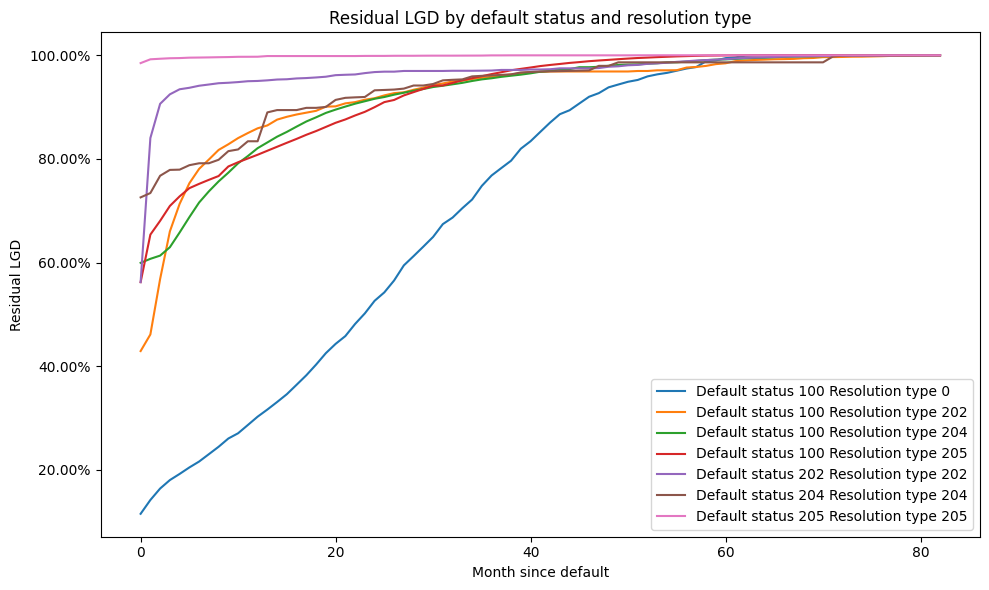

In [8]:
# Plot
plot_residual_lgd(df_res_lgd)